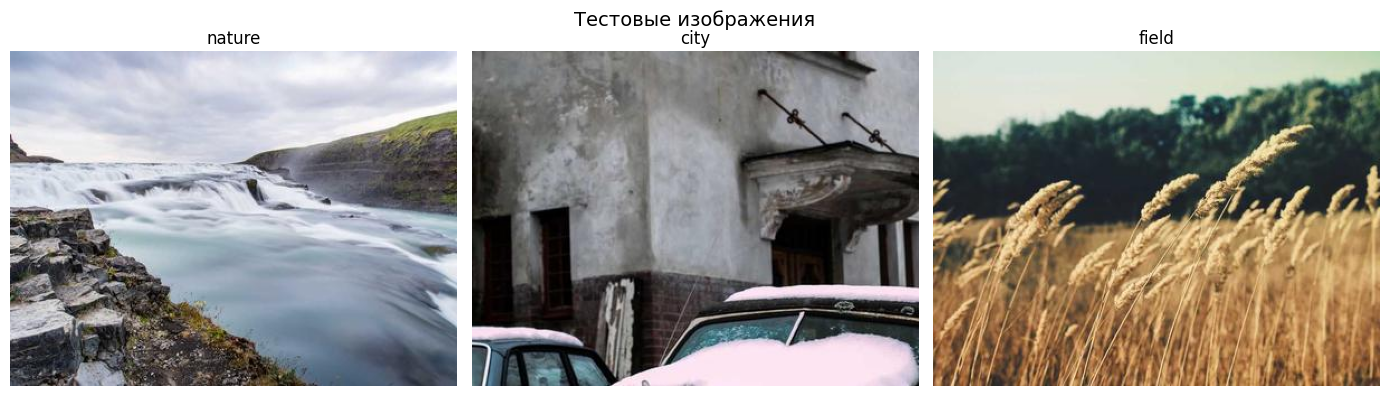

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def load_rgb(path):
    bgr = cv2.imread(path)
    if bgr is None:
        raise RuntimeError(f'Cannot load {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

H, W = 300, 400
def rsz(img): return cv2.resize(img, (W, H))

img1 = rsz(load_rgb('images/nature.jpg'))
img2 = rsz(load_rgb('images/city.jpg'))
img3 = rsz(load_rgb('images/field.jpg'))
gray = cv2.cvtColor(img3, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, im, t in zip(axes, [img1, img2, img3], ['nature', 'city', 'field']):
    ax.imshow(im); ax.set_title(t); ax.axis('off')
plt.suptitle('Тестовые изображения', fontsize=14)
plt.tight_layout(); plt.show()

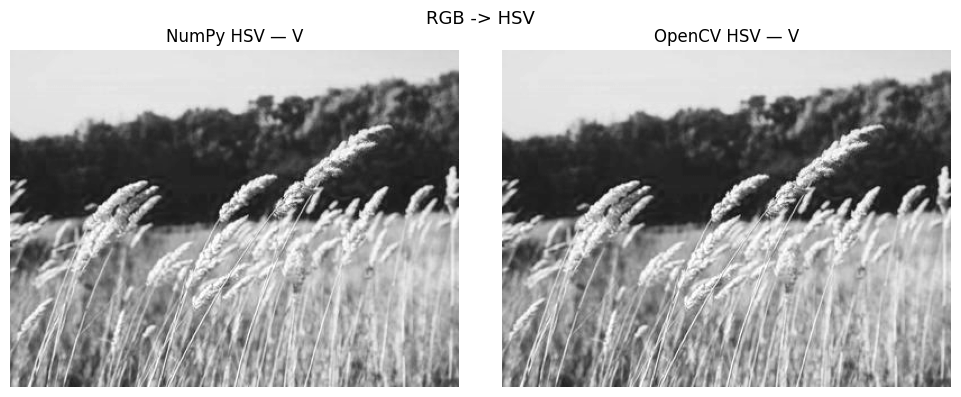

Max H diff: 1.0213
Max S diff: 0.001995
Max V diff: 0.0


In [14]:
def rgb_to_hsv_np(img):
    r = img[:, :, 0].astype(np.float32) / 255.0
    g = img[:, :, 1].astype(np.float32) / 255.0
    b = img[:, :, 2].astype(np.float32) / 255.0

    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    d = cmax - cmin

    v = cmax
    s = np.where(cmax != 0, d / cmax, 0.0)

    h = np.zeros_like(r)
    mr = (cmax == r) & (d != 0)
    mg = (cmax == g) & (d != 0)
    mb = (cmax == b) & (d != 0)
    h[mr] = (60 * ((g[mr] - b[mr]) / d[mr])) % 360
    h[mg] = (60 * ((b[mg] - r[mg]) / d[mg]) + 120) % 360
    h[mb] = (60 * ((r[mb] - g[mb]) / d[mb]) + 240) % 360

    return np.stack([h, s, v], axis=2)


hsv_np = rgb_to_hsv_np(img3)

hsv_cv_raw = cv2.cvtColor(img3, cv2.COLOR_RGB2HSV).astype(np.float32)
hsv_cv = np.stack([
    hsv_cv_raw[:, :, 0] * 2,  
    hsv_cv_raw[:, :, 1] / 255.0,  
    hsv_cv_raw[:, :, 2] / 255.0, 
], axis=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(hsv_np[:, :, 2], cmap='gray'); axes[0].set_title('NumPy HSV — V'); axes[0].axis('off')
axes[1].imshow(hsv_cv[:, :, 2], cmap='gray'); axes[1].set_title('OpenCV HSV — V'); axes[1].axis('off')
plt.suptitle('RGB -> HSV', fontsize=13)
plt.tight_layout(); plt.show()

print('Max H diff:', np.max(np.abs(hsv_np[:, :, 0] - hsv_cv[:, :, 0])).round(4))
print('Max S diff:', np.max(np.abs(hsv_np[:, :, 1] - hsv_cv[:, :, 1])).round(6))
print('Max V diff:', np.max(np.abs(hsv_np[:, :, 2] - hsv_cv[:, :, 2])).round(6))

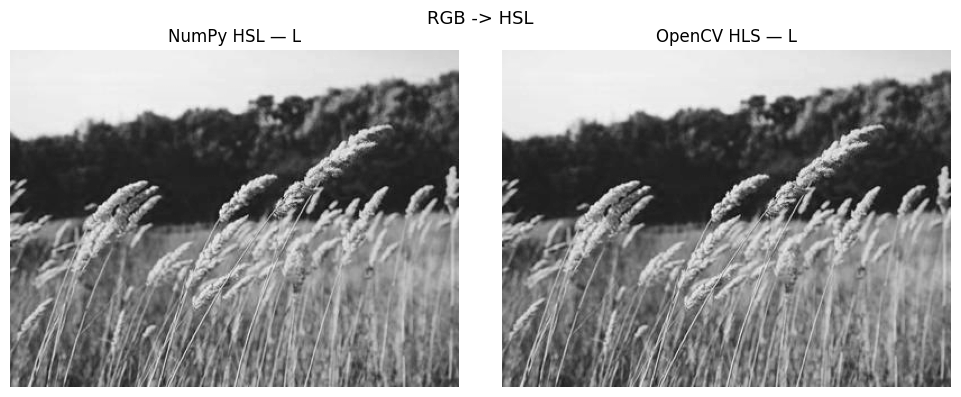

Max H diff: 1.0
Max S diff: 0.001961
Max L diff: 0.001961


In [ ]:
def rgb_to_hsl_np(img):
    r = img[:, :, 0].astype(np.float32) / 255.0
    g = img[:, :, 1].astype(np.float32) / 255.0
    b = img[:, :, 2].astype(np.float32) / 255.0

    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    d = cmax - cmin

    l = (cmax + cmin) / 2.0
    den = 1 - np.abs(2 * l - 1)
    s = np.where((d != 0) & (den != 0), d / den, 0.0)

    h = np.zeros_like(r)
    mr = (cmax == r) & (d != 0)
    mg = (cmax == g) & (d != 0)
    mb = (cmax == b) & (d != 0)
    h[mr] = (60 * ((g[mr] - b[mr]) / d[mr])) % 360
    h[mg] = (60 * ((b[mg] - r[mg]) / d[mg]) + 120) % 360
    h[mb] = (60 * ((r[mb] - g[mb]) / d[mb]) + 240) % 360

    return np.stack([h, s, l], axis=2)


hsl_np = rgb_to_hsl_np(img3)

hls_cv_raw = cv2.cvtColor(img3, cv2.COLOR_RGB2HLS).astype(np.float32)
hsl_cv = np.stack([  # перестановка
    hls_cv_raw[:, :, 0] * 2,
    hls_cv_raw[:, :, 2] / 255.0,
    hls_cv_raw[:, :, 1] / 255.0,
], axis=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(hsl_np[:, :, 2], cmap='gray'); axes[0].set_title('NumPy HSL — L'); axes[0].axis('off')
axes[1].imshow(hsl_cv[:, :, 2], cmap='gray'); axes[1].set_title('OpenCV HLS — L'); axes[1].axis('off')
plt.suptitle('RGB -> HSL', fontsize=13)
plt.tight_layout(); plt.show()

print('Max H diff:', np.max(np.abs(hsl_np[:, :, 0] - hsl_cv[:, :, 0])).round(4))
print('Max S diff:', np.max(np.abs(hsl_np[:, :, 1] - hsl_cv[:, :, 1])).round(6))
print('Max L diff:', np.max(np.abs(hsl_np[:, :, 2] - hsl_cv[:, :, 2])).round(6))

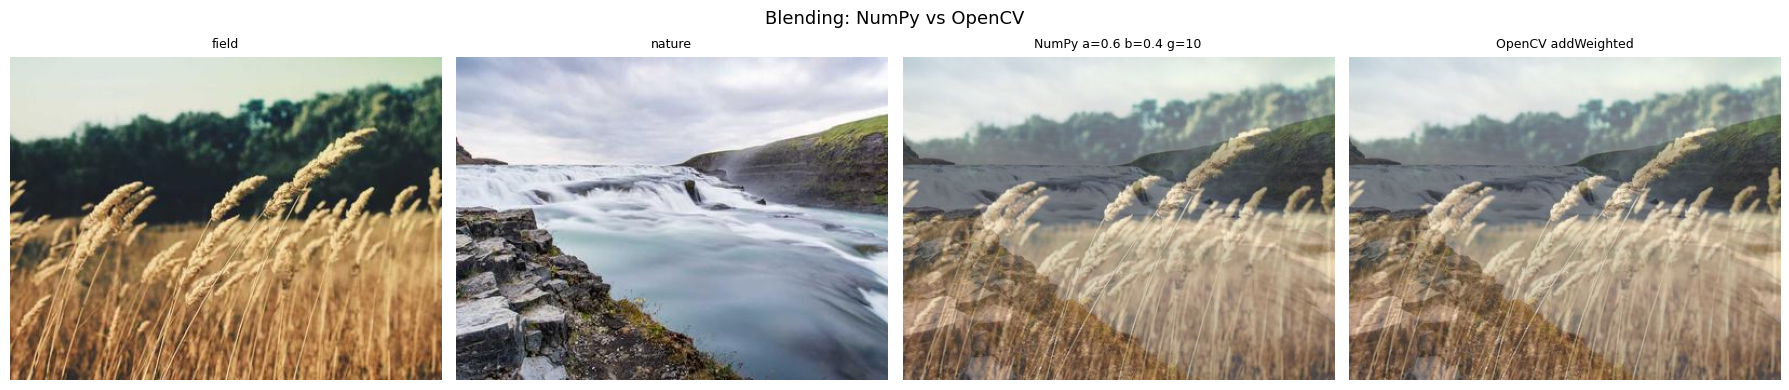

Max diff: 1


In [ ]:
def blend_np(a, b, alpha=0.5, beta=0.5, gamma=0):
    out = alpha * a.astype(np.float32) + beta * b.astype(np.float32) + gamma
    return np.clip(out, 0, 255).astype(np.uint8)


alpha, beta, gamma = 0.6, 0.4, 10

blended_np = blend_np(img3, img1, alpha, beta, gamma)
blended_cv = cv2.addWeighted(img3, alpha, img1, beta, gamma)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, im, t in zip(axes,
        [img3, img1, blended_np, blended_cv],
        ['field', 'nature', f'NumPy a={alpha} b={beta} g={gamma}', 'OpenCV addWeighted']):
    ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis('off')
plt.suptitle('Blending: NumPy vs OpenCV', fontsize=13)
plt.tight_layout(); plt.show()

print('Max diff:', np.abs(blended_np.astype(int) - blended_cv.astype(int)).max())

In [17]:
def thresh_binary(g, t):      return np.where(g > t, 255, 0).astype(np.uint8)
def thresh_binary_inv(g, t):  return np.where(g > t, 0, 255).astype(np.uint8)
def thresh_to_zero(g, t):     return np.where(g > t, g, 0).astype(np.uint8)
def thresh_to_zero_inv(g, t): return np.where(g > t, 0, g).astype(np.uint8)
def thresh_trunc(g, t):       return np.where(g > t, t, g).astype(np.uint8)

In [18]:

def conv2d_np(img, kernel, clip=True):
    img = img.astype(np.float32)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='reflect')
    H, W = img.shape
    out = np.zeros((H, W), dtype=np.float32)
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i+H, j:j+W]
    if clip:
        return np.clip(out, 0, 255).astype(np.uint8)
    return out

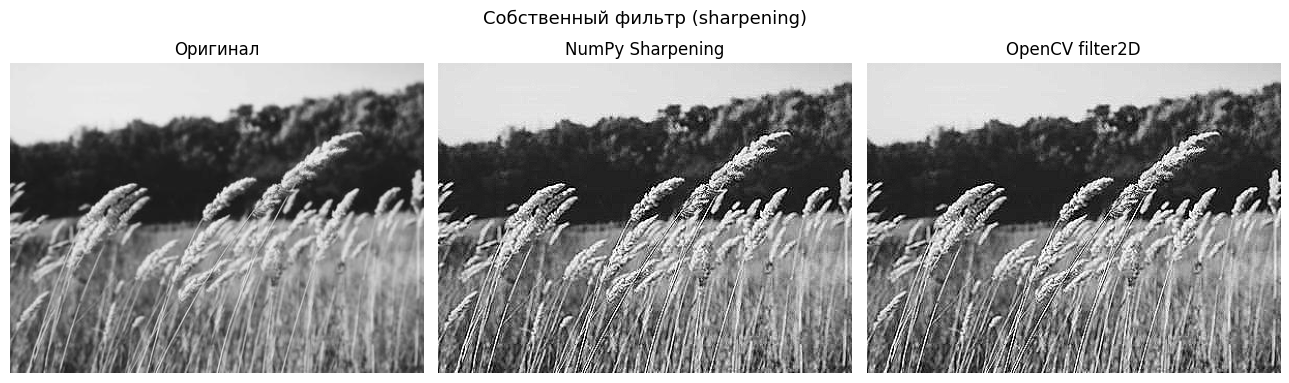

Max diff: 0


In [19]:
sharpen_kernel = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]], dtype=np.float32)

custom_np = conv2d_np(gray, sharpen_kernel)
custom_cv = cv2.filter2D(gray, -1, sharpen_kernel)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, im, t in zip(axes, [gray, custom_np, custom_cv],
                     ['Оригинал', 'NumPy Sharpening', 'OpenCV filter2D']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.suptitle('Собственный фильтр (sharpening)', fontsize=13)
plt.tight_layout(); plt.show()

print('Max diff:', np.abs(custom_np.astype(int) - custom_cv.astype(int)).max())

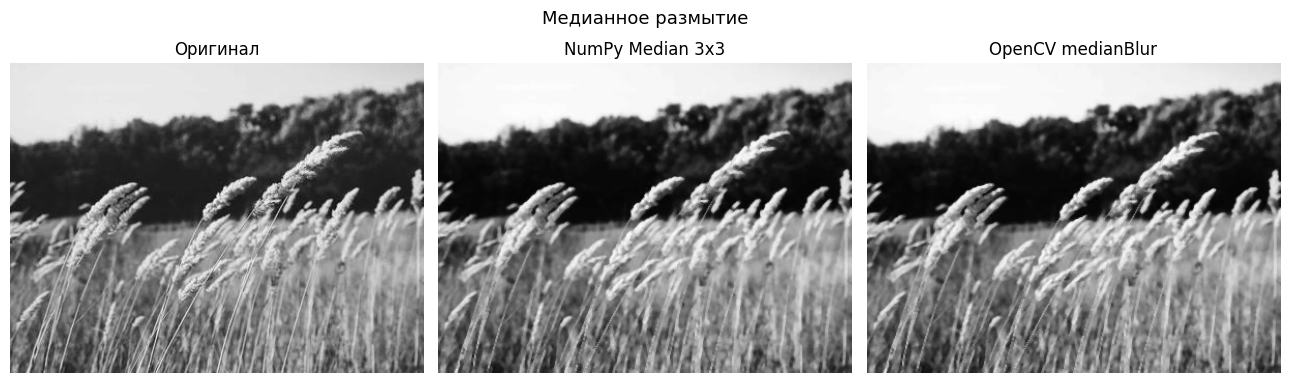

Max diff: 52


In [20]:
def median_blur_np(img, ksize=3):
    p = ksize // 2
    padded = np.pad(img.astype(np.float32), p, mode='reflect')
    H, W = img.shape
    out = np.zeros((H, W), dtype=np.float32)
    for i in range(H):
        for j in range(W):
            out[i, j] = np.median(padded[i:i+ksize, j:j+ksize])
    return out.astype(np.uint8)


median_np = median_blur_np(gray, 3)
median_cv = cv2.medianBlur(gray, 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, im, t in zip(axes, [gray, median_np, median_cv],
                     ['Оригинал', 'NumPy Median 3x3', 'OpenCV medianBlur']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.suptitle('Медианное размытие', fontsize=13)
plt.tight_layout(); plt.show()

print('Max diff:', np.abs(median_np.astype(int) - median_cv.astype(int)).max())

Гауссово ядро 5x5:
[[0.01215 0.02611 0.0337  0.02611 0.01215]
 [0.02611 0.05613 0.07244 0.05613 0.02611]
 [0.0337  0.07244 0.09349 0.07244 0.0337 ]
 [0.02611 0.05613 0.07244 0.05613 0.02611]
 [0.01215 0.02611 0.0337  0.02611 0.01215]]


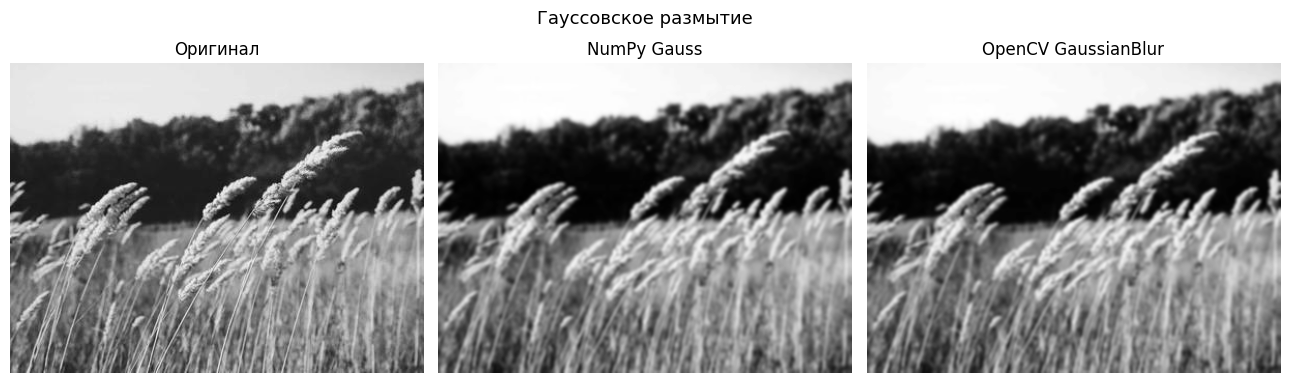

Max diff: 1


In [21]:
def make_gauss_kernel_2d(ksize=5, sigma=1.0):
    ax = np.arange(ksize) - ksize // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return (kernel / kernel.sum()).astype(np.float32)


KSIZE, SIGMA = 5, 1.4
gauss_kernel = make_gauss_kernel_2d(KSIZE, SIGMA)

print('Гауссово ядро 5x5:')
print(np.round(gauss_kernel, 5))

gauss_np = conv2d_np(gray, gauss_kernel)
gauss_cv = cv2.GaussianBlur(gray, (KSIZE, KSIZE), SIGMA)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, im, t in zip(axes, [gray, gauss_np, gauss_cv],
                     ['Оригинал', 'NumPy Gauss', 'OpenCV GaussianBlur']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.suptitle('Гауссовское размытие', fontsize=13)
plt.tight_layout(); plt.show()

print('Max diff:', np.abs(gauss_np.astype(int) - gauss_cv.astype(int)).max())

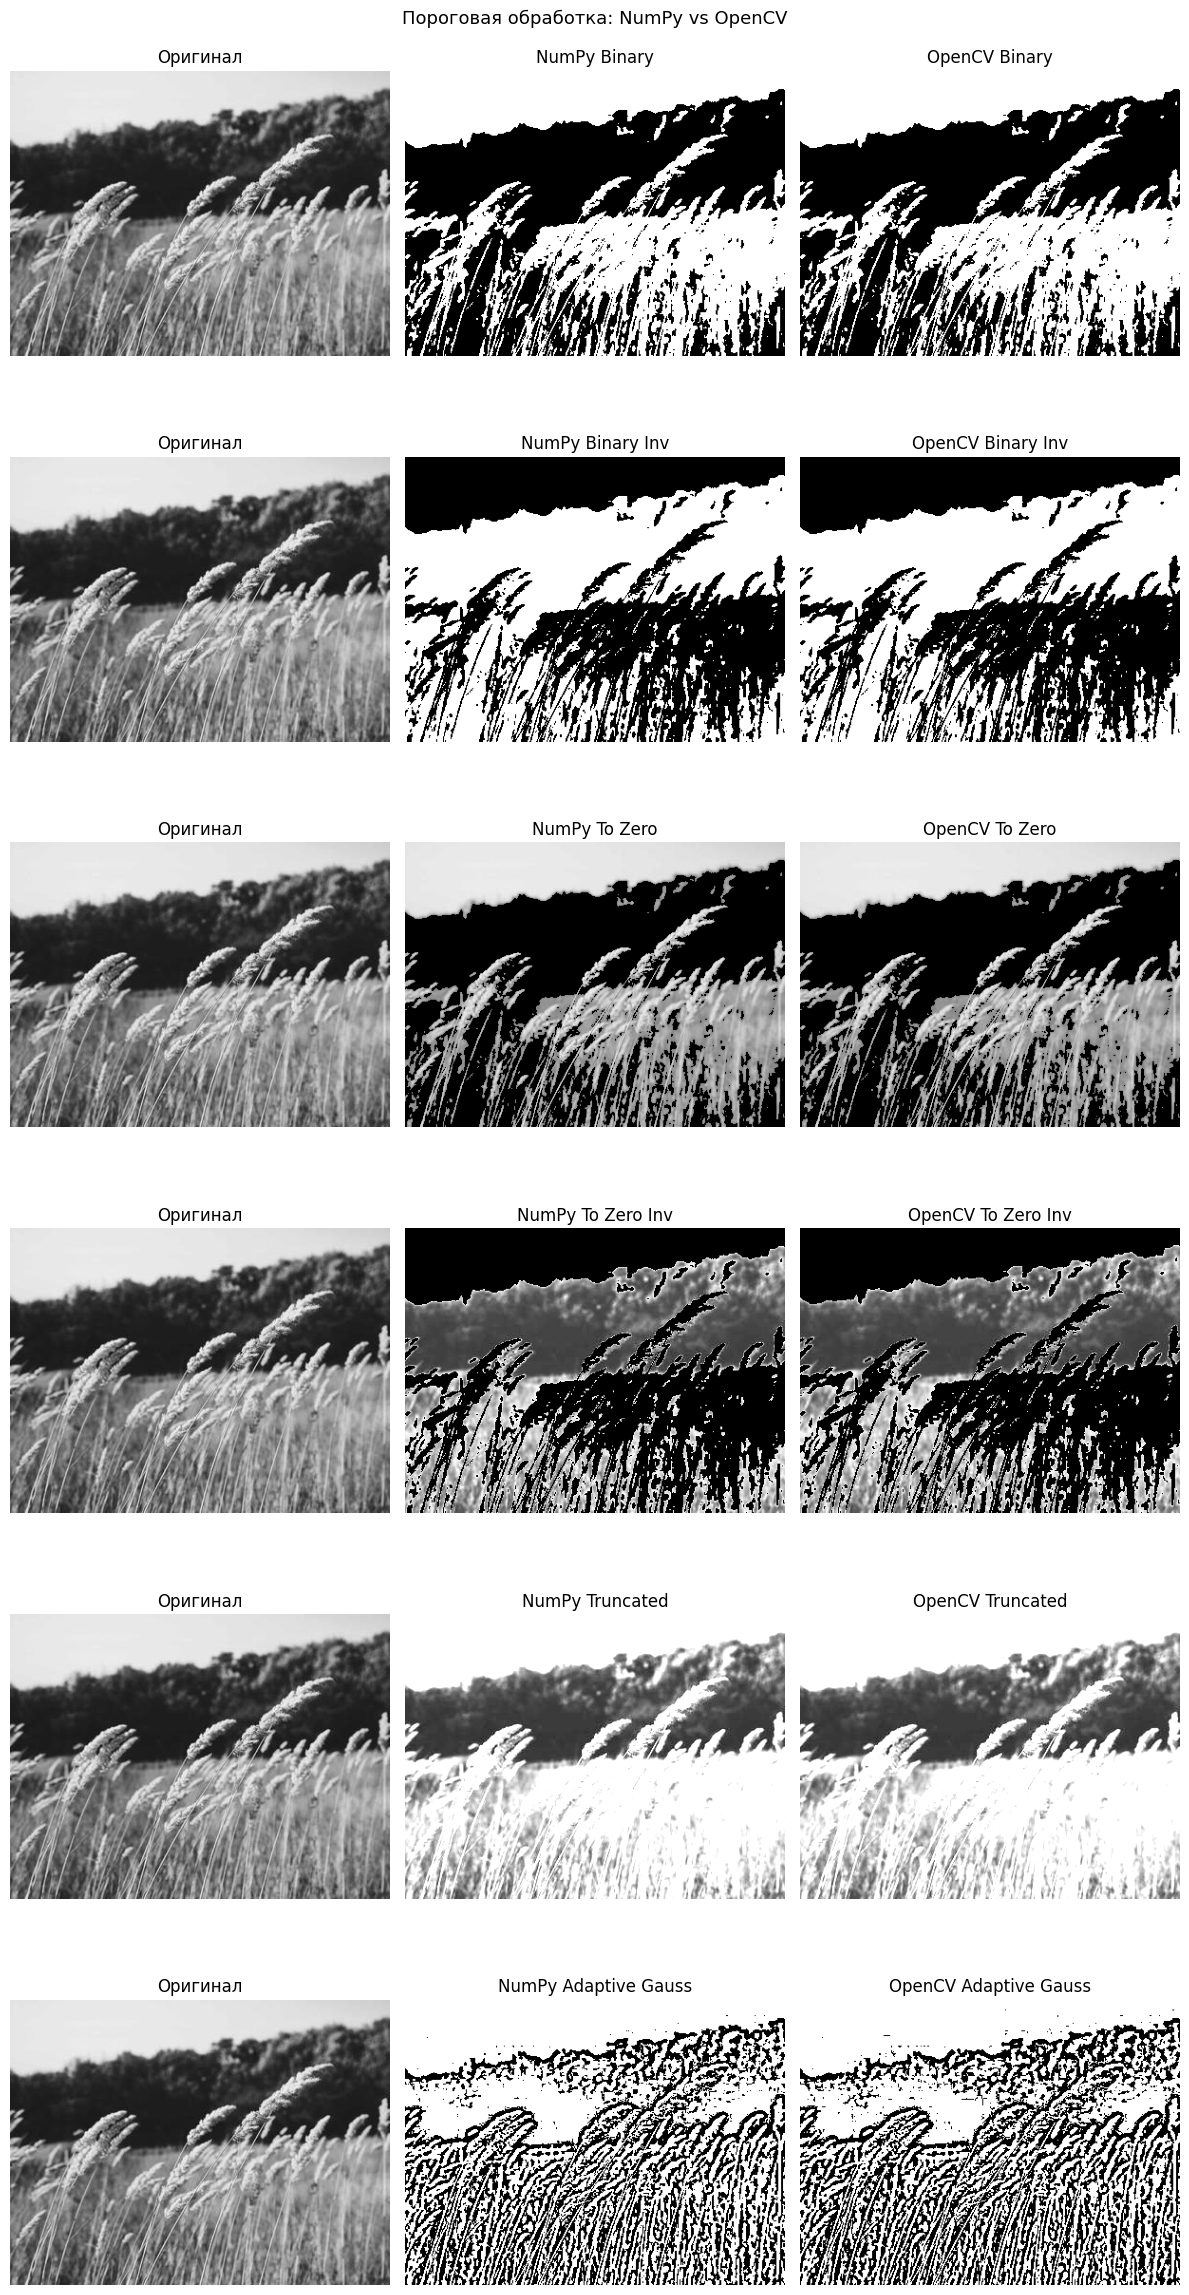

In [22]:
def adaptive_gauss_thresh_np(img, block=11, C=2):
    sigma = 0.3 * ((block - 1) * 0.5 - 1) + 0.8
    local_mean = conv2d_np(img, make_gauss_kernel_2d(block, sigma), clip=False)
    return np.where(img.astype(np.float32) > (local_mean - C), 255, 0).astype(np.uint8)


T = 127

methods_np = {
    'Binary':         thresh_binary(gray, T),
    'Binary Inv':     thresh_binary_inv(gray, T),
    'To Zero':        thresh_to_zero(gray, T),
    'To Zero Inv':    thresh_to_zero_inv(gray, T),
    'Truncated':      thresh_trunc(gray, T),
    'Adaptive Gauss': adaptive_gauss_thresh_np(gray, 11, 2),
}

methods_cv = {
    'Binary':         cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)[1],
    'Binary Inv':     cv2.threshold(gray, T, 255, cv2.THRESH_BINARY_INV)[1],
    'To Zero':        cv2.threshold(gray, T, 255, cv2.THRESH_TOZERO)[1],
    'To Zero Inv':    cv2.threshold(gray, T, 255, cv2.THRESH_TOZERO_INV)[1],
    'Truncated':      cv2.threshold(gray, T, 255, cv2.THRESH_TRUNC)[1],
    'Adaptive Gauss': cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2),
}

names = list(methods_np.keys())
fig, axes = plt.subplots(len(names), 3, figsize=(12, 24))

for row, name in enumerate(names):
    axes[row, 0].imshow(gray, cmap='gray')
    axes[row, 0].set_title('Оригинал'); axes[row, 0].axis('off')
    axes[row, 1].imshow(methods_np[name], cmap='gray')
    axes[row, 1].set_title(f'NumPy {name}'); axes[row, 1].axis('off')
    axes[row, 2].imshow(methods_cv[name], cmap='gray')
    axes[row, 2].set_title(f'OpenCV {name}'); axes[row, 2].axis('off')

plt.suptitle('Пороговая обработка: NumPy vs OpenCV', fontsize=13)
plt.tight_layout(); plt.show()

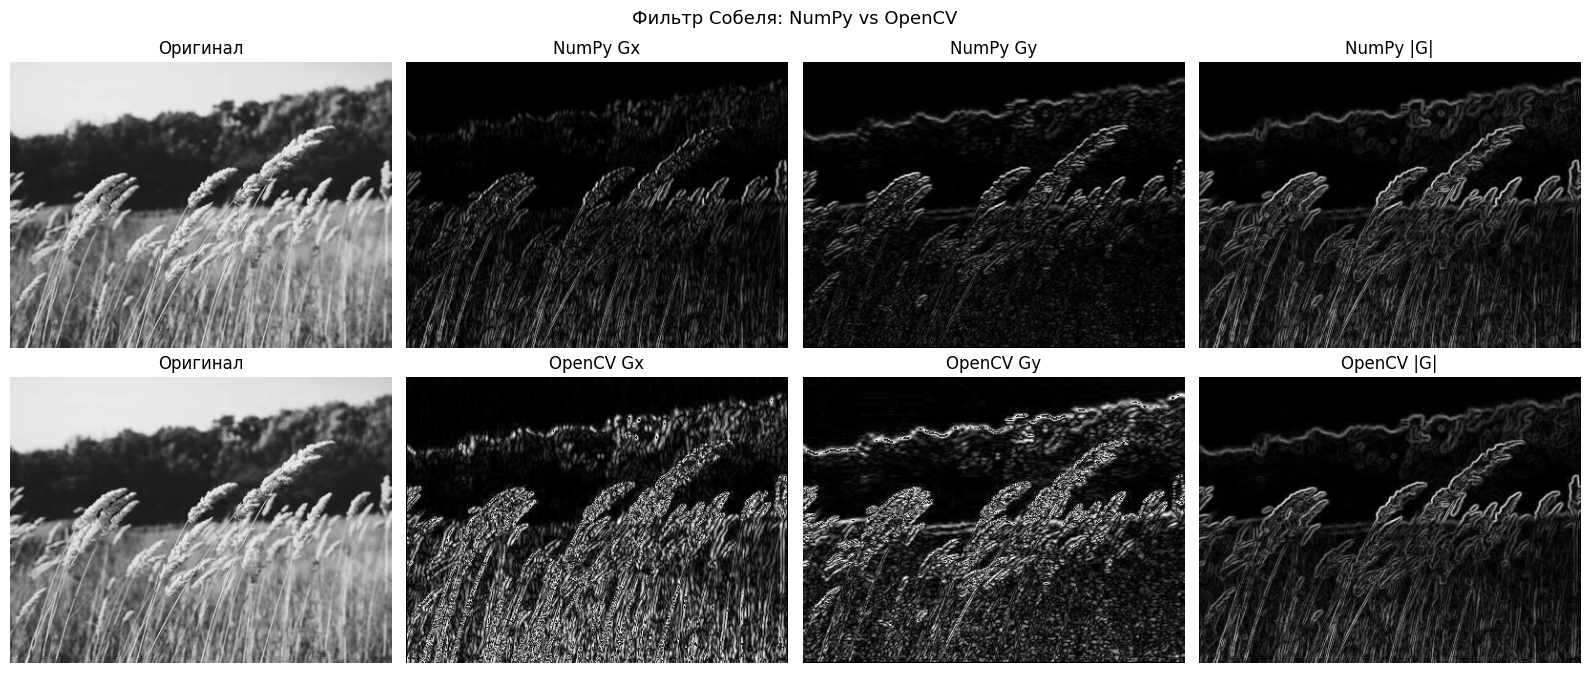

Max |G| diff: 0


In [23]:
def sobel_np(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Ky = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=np.float32)

    Gx = conv2d_np(img, Kx, clip=False)
    Gy = conv2d_np(img, Ky, clip=False)
    G  = np.sqrt(Gx**2 + Gy**2)

    def norm(x):
        return np.clip(np.abs(x) / (np.abs(x).max() + 1e-8) * 255, 0, 255).astype(np.uint8)

    return norm(Gx), norm(Gy), norm(G)


Gx_np, Gy_np, G_np = sobel_np(gray)

Gx_cv = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
Gy_cv = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
G_cv  = np.sqrt(Gx_cv**2 + Gy_cv**2)
G_cv  = np.clip(G_cv / G_cv.max() * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
row_data = [
    [gray, Gx_np, Gy_np, G_np],
    [gray, np.abs(Gx_cv).astype(np.uint8), np.abs(Gy_cv).astype(np.uint8), G_cv],
]
row_titles = [
    ['Оригинал', 'NumPy Gx', 'NumPy Gy', 'NumPy |G|'],
    ['Оригинал', 'OpenCV Gx', 'OpenCV Gy', 'OpenCV |G|'],
]
for r in range(2):
    for c in range(4):
        axes[r, c].imshow(row_data[r][c], cmap='gray')
        axes[r, c].set_title(row_titles[r][c])
        axes[r, c].axis('off')

plt.suptitle('Фильтр Собеля: NumPy vs OpenCV', fontsize=13)
plt.tight_layout(); plt.show()

print('Max |G| diff:', np.abs(G_np.astype(int) - G_cv.astype(int)).max())

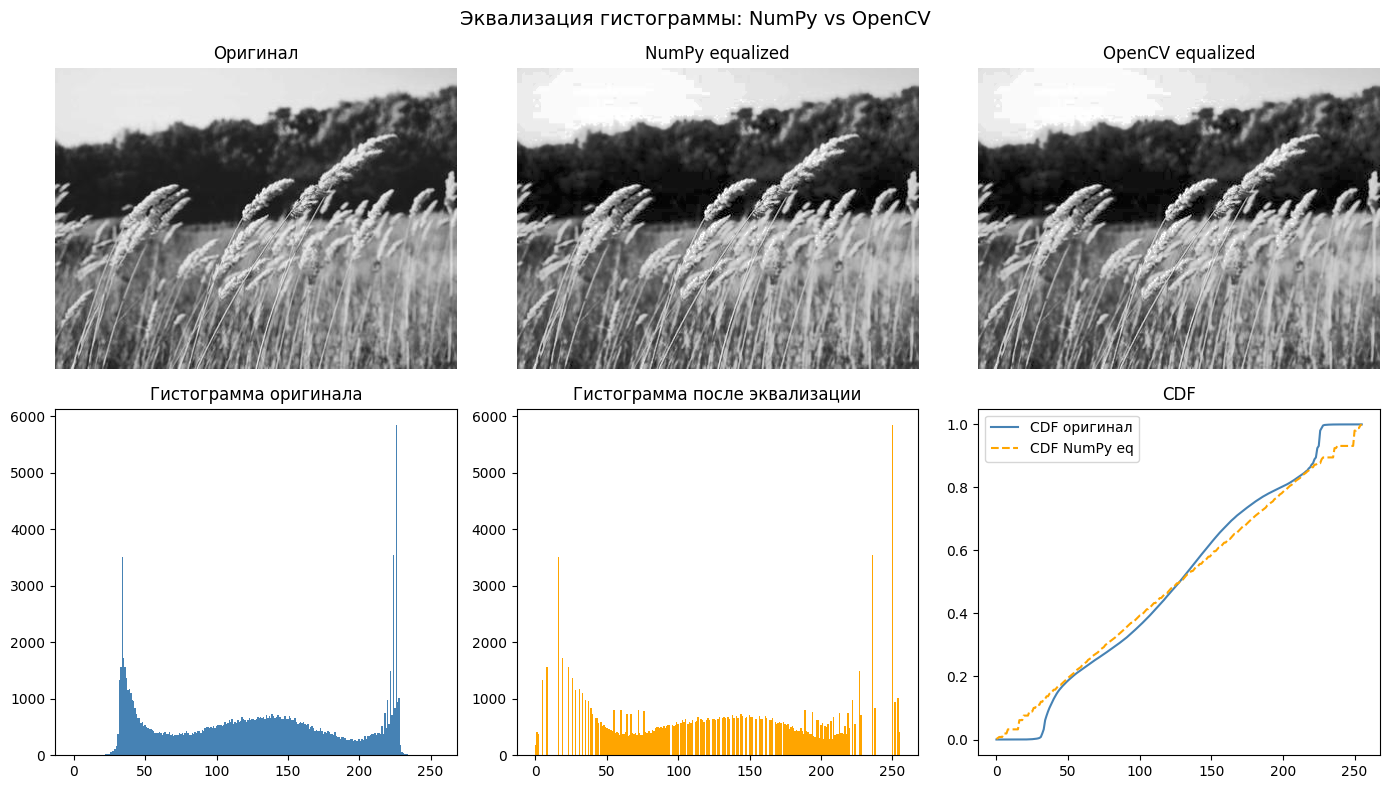

Max diff NumPy vs OpenCV: 0


In [24]:
def hist_equalize_np(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    # 2. CDF — кумулятивная сумма
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    N = img.size
    # 3. LUT — таблица замены значений
    lut = np.round((cdf - cdf_min) / (N - cdf_min) * 255).astype(np.uint8)
    return lut[img], hist, cdf


eq_np, hist_orig, cdf_orig = hist_equalize_np(gray)
eq_cv = cv2.equalizeHist(gray)

hist_eq_np, _ = np.histogram(eq_np.flatten(), bins=256, range=(0, 256))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(gray,  cmap='gray'); axes[0, 0].set_title('Оригинал');        axes[0, 0].axis('off')
axes[0, 1].imshow(eq_np, cmap='gray'); axes[0, 1].set_title('NumPy equalized');  axes[0, 1].axis('off')
axes[0, 2].imshow(eq_cv, cmap='gray'); axes[0, 2].set_title('OpenCV equalized'); axes[0, 2].axis('off')

axes[1, 0].bar(range(256), hist_orig,  color='steelblue', width=1); axes[1, 0].set_title('Гистограмма оригинала')
axes[1, 1].bar(range(256), hist_eq_np, color='orange',    width=1); axes[1, 1].set_title('Гистограмма после эквализации')

cdf_eq = np.histogram(eq_np.flatten(), 256, (0, 256))[0].cumsum()
axes[1, 2].plot(cdf_orig / cdf_orig.max(), label='CDF оригинал', color='steelblue')
axes[1, 2].plot(cdf_eq / cdf_eq.max(),     label='CDF NumPy eq', color='orange', linestyle='--')
axes[1, 2].set_title('CDF'); axes[1, 2].legend()

plt.suptitle('Эквализация гистограммы: NumPy vs OpenCV', fontsize=14)
plt.tight_layout(); plt.show()

print('Max diff NumPy vs OpenCV:', np.abs(eq_np.astype(int) - eq_cv.astype(int)).max())